In [1]:
!nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism
from neuron import h
import plotly.graph_objects as go
import matplotlib.colors as mcolors
from neuron.units import ms, mV
import plotly.io as pio
from matplotlib import pyplot, cm
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位

def plot_curve(ax2,x,y,color='black',title='', linestyle='-',xlim=[0,100],dx=20,ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', ylabel = 'Frequency/Hz', label='',ynum_decimals =1):
    if color:
        ax2.plot(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, label=label)
    else:
        ax2.plot(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label)
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
    #     ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if xlim:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

h.load_file('nrngui.hoc')
h.load_file("import3d.hoc")

morphologyFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc"
biophysicalModelTemplateFilename = "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/PFCtemplate.hoc"

h.load_file(biophysicalModelTemplateFilename)

/home/wzl/anaconda/envs/neuron9/bin/nrnivmodl:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
INFO : Using neuron-nightly Package (Developer Version)
/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/local_mean_conductance
cfiles =
Mod files: "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampain.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/ampa.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechanism/cadynin.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/mechan

--No graphics will be displayed.


1.0

0.0746802999053033


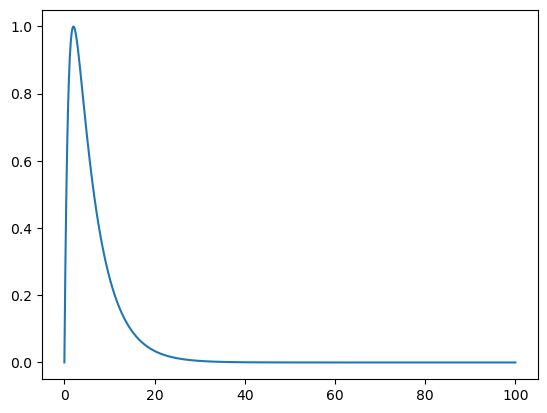

In [2]:
run_dt=0.1
syn_tau1 = 1.
syn_tau2 = 5.
fE = 1e-3
t=np.arange(0,100+run_dt,run_dt)
NE = ((syn_tau1/syn_tau2)**(syn_tau1/(syn_tau2-syn_tau1))-(syn_tau1/syn_tau2)**(syn_tau2/(syn_tau2-syn_tau1)))**-1
uE = NE*(np.exp(-t/syn_tau2)-np.exp(-t/syn_tau1))
plt.plot(t,uE)
ground_truth = np.mean(uE)
print(ground_truth)

In [3]:
neuron = h.FScell(morphologyFilename)

Opening gjhui/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/FS/TzilivakiEtal_FSBCs_model/Multicompartmental_Biophysical_models/experiment/model_reconstructions/PFC/Mar11.hoc
Denrite No!
1
1
1
0
0
1
1
1
1
1
0
0
0
0
1
1
1
1
1
1
1
1
0
0
0
0
0
1
1
1
0
1
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
0
0
1
0
1
1
1


In [4]:
def shapeplot(var_dend,
    figname = 'neurondendriticEPSP_fE1e-3', cmap = cm.jet,
    savefig = False, colorbarlabel='EPSP/mV', ticklabels=False,
    tickmin=0, tickmax=50, dt=10, setv=False, vmin=0., vmax=1.):
    
    # L5PC = h.L5PCtemplate(morphologyFilename)
    for i in range(len(neuron.soma)):
        neuron.soma[i].v = 0.
    
    for i in range(len(neuron.dend)):
        neuron.dend[i].v = var_dend[i]
    
    for i in range(len(neuron.axon)):
        neuron.axon[i].v = 0.

 
    v_vals = [seg.v for sec in h.allsec() for seg in sec]
    print(min(v_vals),max(v_vals))
    if setv:
        minv= vmin
        maxv = vmax
    else:
        minv= min(v_vals)
        maxv= max(v_vals)

            
    ps = h.PlotShape(False)  # False tells h.PlotShape not to use NEURON's gui
    ps.show(0)
    ps.variable('v')
    ps.scale(minv, maxv)
    ax = ps.plot(pyplot, cmap=cmap)
    ps.show(0)

    # # 设置坐标轴范围
    # ax.set_xlim([-700, 0])  # 替换 xmin 和 xmax 为所需的 x 范围
    # ax.set_ylim([500, 1400])  # 替换 ymin 和 ymax 为所需的 y 范围
    # ax.set_zlim([-1000, 00])  # 替换 zmin 和 zmax 为所需的 z 范围
    # ax.view_init(elev=280, azim=98)
    # 关闭网格
    ax.grid(False)
    # 关闭坐标轴
    ax.axis('off')
    # 保存为 EPS 格式
    if savefig:
        plt.savefig(figname+'.eps', format='eps')
    
    
    
    # # second figure
    # ps = h.PlotShape(True)
    # ps.variable("v")
    # ps.scale(minv, maxv)
    # fig = ps.plot(plotly, cmap=cmap)


    # # Create a colormap function
    # colormap = cm.ScalarMappable(cmap=cmap, 
    # norm=mcolors.Normalize(vmin=0, vmax=1)).to_rgba

    # # Map the normalized values to a Plotly colorscale as strings
    # plotly_colorscale = [[v, f'rgb{tuple(int(255 * c) for c in colormap(v)[:3])}'] for v in np.linspace(0, 1, cmap.N)]

    # # Create a separate scatter plot for the colorbar
    # colorbar_trace = go.Scatter(
    #     x=[0],
    #     y=[0],
    #     mode='markers',
    #     marker=dict(
    #         colorscale=plotly_colorscale,
    #         cmin=minv,
    #         cmax=maxv,
    #         colorbar=dict(
    #             title=colorbarlabel,
    #             thickness=20  # Adjust the thickness of the colorbar
    #         ),
    #         showscale=True
    #     )
    # )

    # # Add the colorbar trace to the figure
    # fig.add_trace(colorbar_trace)
    # fig.update_xaxes(showticklabels=False, showgrid=True)
    # fig.update_yaxes(showticklabels=False, showgrid=True)
    # fig.update_layout(
    #     plot_bgcolor='rgba(0,0,0,0)'
    # )

    # fig.show()

    # 创建自定义的颜色映射
    cmap = cmap
    colormap = cm.ScalarMappable(cmap=cmap, 
            norm=mcolors.Normalize(vmin=minv, vmax=maxv))

    # 创建一个新的图形和轴
    fig, ax = plt.subplots(figsize=(6, 1))

    # 绘制颜色条
    cbar = plt.colorbar(colormap, cax=ax, orientation='horizontal')
    cbar.set_label(colorbarlabel)
    if ticklabels:
        cbar.set_ticks(np.arange(tickmin, tickmax, dt))
        cbar.set_ticklabels([f'{i}' for i in np.arange(tickmin, tickmax, dt)])

    # 设置图的边界
    plt.tight_layout()

    if savefig:
        # 保存为 EPS 格式
        plt.savefig(figname+'colorbar'+'.eps', format='eps')

    # 显示图形（可选）
    plt.show()
    
    print(minv,maxv)

    

0.014901536151649285 0.1739259448627234
0.0 0.1739259448627234


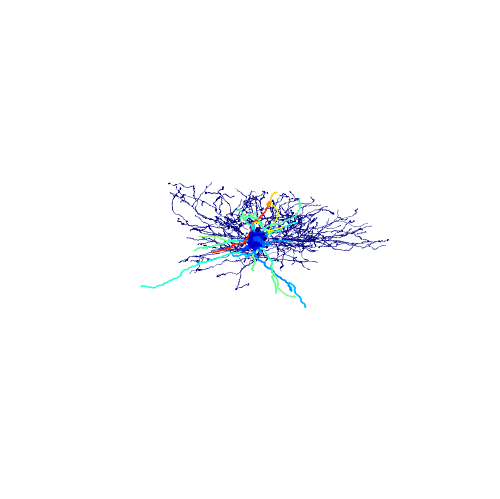

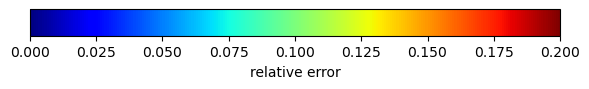

0.0 0.2


In [8]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_passive_dendloc68_fE1e4.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 1e-4

var_dend = np.abs(estimated_mean_cond_trad_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend,
        figname = 'passive_local_trad_fE1e4', 
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=0.2, dt=0.1, cmap=cm.jet, setv=True, vmin=0., vmax=0.2)

0.02248603813056729 0.4938573507189047
0.0 0.4938573507189047


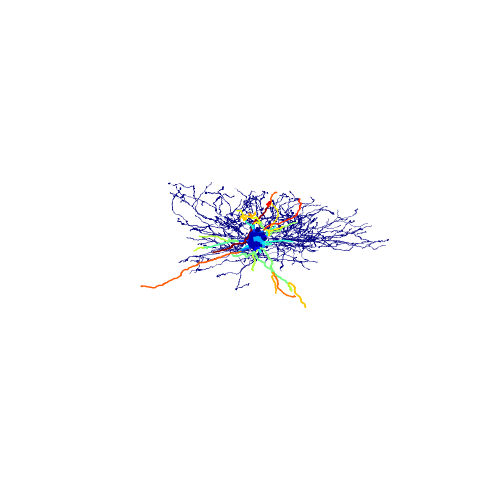

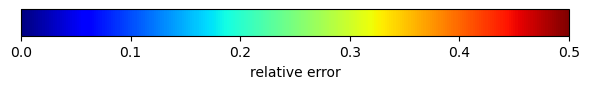

0.0 0.5


In [12]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_passive_dendloc68_fI3e3.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 3e-3

var_dend = np.abs(estimated_mean_cond_trad_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend,
        figname = 'passive_local_trad_fI3e3', 
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=0.2, dt=0.1, cmap=cm.jet, setv=True, vmin=0., vmax=0.5)

0.008357012643902978 0.4498139083955554
0.0 0.4498139083955554


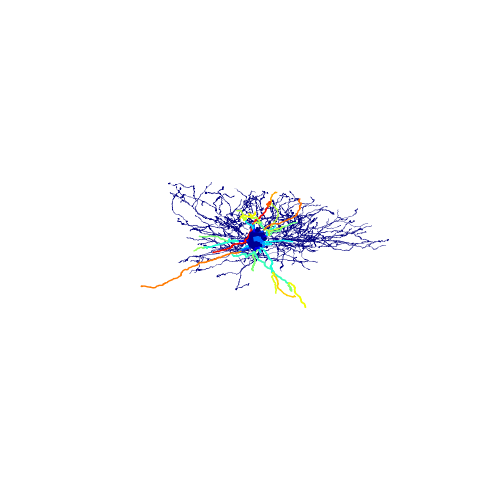

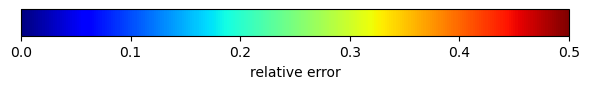

0.0 0.5


In [10]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_passive_dendloc68_fI3e3.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 3e-3

var_dend = np.abs(estimated_mean_cond_us_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend,
        figname = 'passive_local_us_fI3e3', 
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=0.2, dt=0.1, cmap=cm.jet, setv=True, vmin=0., vmax=0.5)

0.008540961613170766 0.45113203052875767
0.0 0.45113203052875767


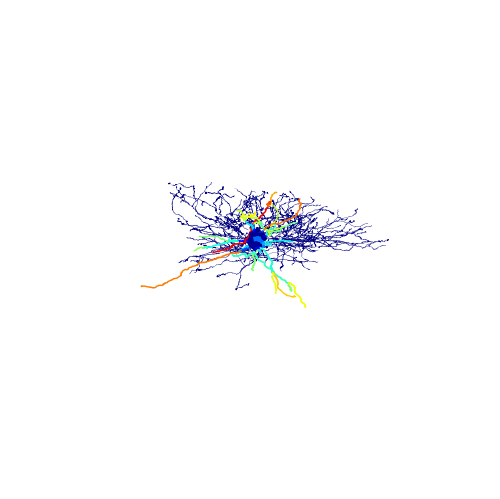

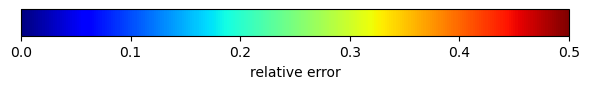

0.0 0.5


In [ ]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_active_dendloc68_fI3e3.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 3e-3

var_dend = np.abs(estimated_mean_cond_us_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend,
        figname = 'active_local_us_fI3e3', 
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=0.2, dt=0.1, cmap=cm.jet, setv=True, vmin=0., vmax=0.5)

0.022804949894558606 0.4982005306820477
0.0 0.4982005306820477


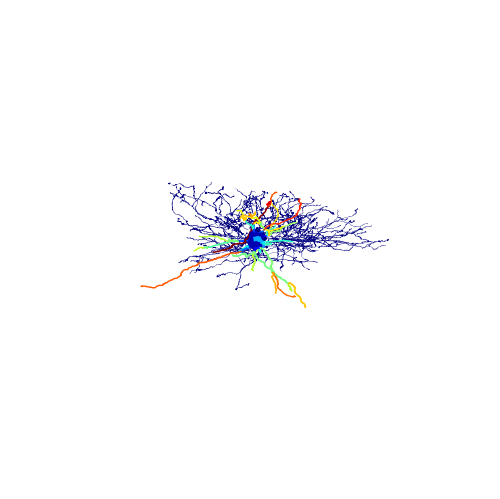

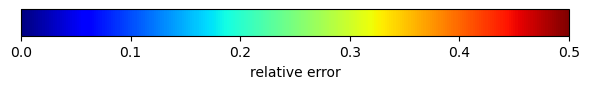

0.0 0.5


In [7]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_active_dendloc68_fI3e3.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 3e-3

var_dend = np.abs(estimated_mean_cond_trad_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend,
        figname = 'active_local_trad_fI3e3', 
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=0.2, dt=0.1, cmap=cm.jet, setv=True, vmin=0., vmax=0.5)